In [12]:
import tensorflow as tf 

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/full",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=None
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/full",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=None
)

Found 34088 files belonging to 2 classes.
Using 27271 files for training.
Found 34088 files belonging to 2 classes.
Using 6817 files for validation.


In [2]:
print(train_ds.class_names)

['fake', 'real']


In [13]:
preprocess_input = tf.keras.applications.efficientnet.preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).batch(32)
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y)).batch(32)

In [14]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,        # Remove ImageNet classification head
    weights='imagenet',       # Use pretrained weights
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Freeze pretrained weights initially

In [15]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),   # Replaces Flatten, more efficient
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),               # Prevents overfitting
    layers.Dense(1, activation='sigmoid')  # Fake(0) or Real(1)
])

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
 12/853 ━━━━━━━━━━━━━━━━━━━━ 24:56 2s/step - accuracy: 0.4853 - loss: 0.7453

KeyboardInterrupt: 

In [31]:
print(model.evaluate(val_ds))

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 374ms/step - accuracy: 0.9736 - loss: 0.1215
[0.12145987898111343, 0.9736379384994507]


In [32]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [33]:
accuracy=history.history["accuracy"]
val_accuracy=history.history["val_accuracy"]

print(accuracy[-1])
print(val_accuracy[-1])

0.9833260178565979
0.9736379384994507


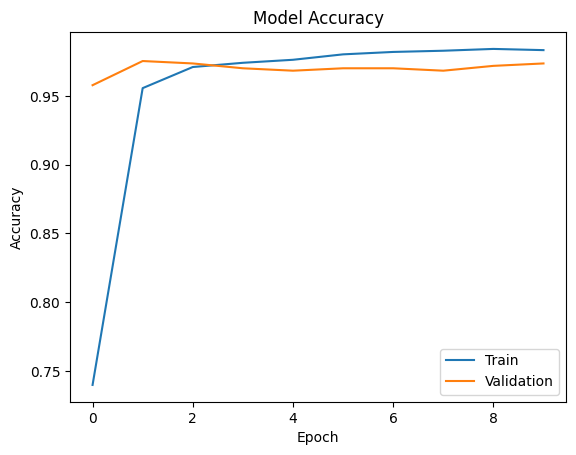

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [35]:
model.save("cnn_model.keras")